In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import requests

Index(['referenceTime', 'value'], dtype='str')


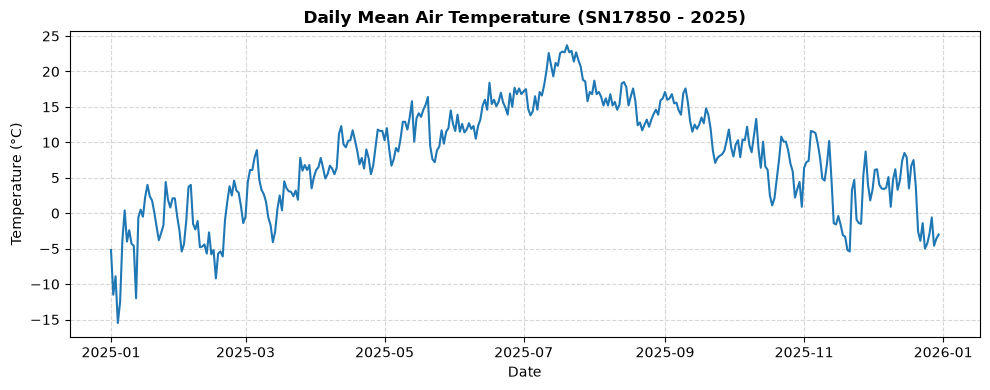


--- Temperature Summary Statistics (2025) ---
Metric  Temperature (°C)
  Mean               7.9
Median               8.4
   Min             -15.5
   Max              23.7


In [6]:
# Prepare the data retrieving connection
CLIENT_ID = "18184a8d-8fdc-46f3-86fc-ec35fae13b99"
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2025-12-31',
}

response = requests.get(endpoint, parameters, auth=(CLIENT_ID, ""))
json_data = response.json()

# Transforms JSON data to a local-callable list
records = []
if response.status_code == 200:
    for item in json_data["data"]:
        records.append(
            {
                "referenceTime": item["referenceTime"],
                "value": item["observations"][0]["value"],
            }
        )

# Transform the list to a dataframe
df = pd.DataFrame(records)
print(df.columns)
df["referenceTime"] = pd.to_datetime(df["referenceTime"])
df.set_index("referenceTime", inplace=True)

# Plot
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(df.index, df["value"], color="#1f77b4", linewidth=1.5)
plt.title(
    "Daily Mean Air Temperature (SN17850 - 2025)", fontsize=12, fontweight="bold"
)
plt.xlabel("Date", fontsize=10)
plt.ylabel("Temperature (°C)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Summary Statistics Table
summary_df = pd.DataFrame(
    {
        "Metric": ["Mean", "Median", "Min", "Max"],
        "Temperature (°C)": [
            df["value"].mean(),
            df["value"].median(),
            df["value"].min(),
            df["value"].max(),
        ],
    }
).round(2)

print("\n--- Temperature Summary Statistics (2025) ---")
print(summary_df.to_string(index=False))

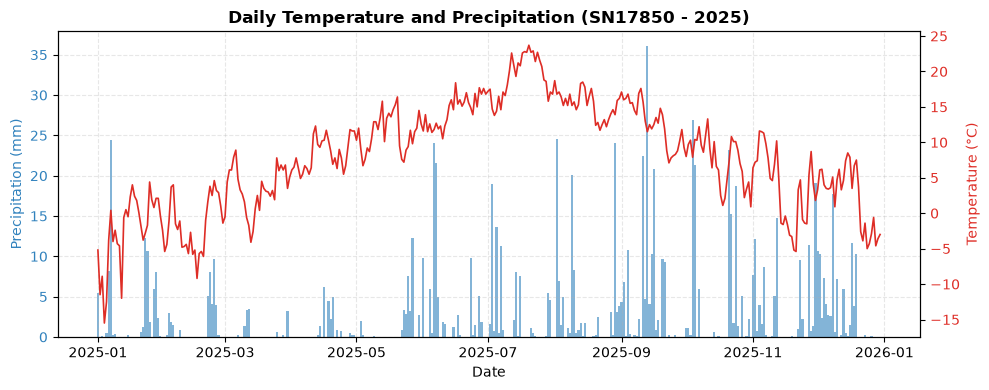

In [7]:
# Assign request to API about specific data of precipitation
parameters = {
    "sources": "SN17850",
    "elements": "sum(precipitation_amount P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

response = requests.get(endpoint, parameters, auth=(CLIENT_ID, ""))
json_data = response.json()

precip_records = [
    {
        "referenceTime": item["referenceTime"],
        "precip": item["observations"][0]["value"],
    }
    for item in json_data["data"]
]

# Load precipitation data named precip_df
precip_df = pd.DataFrame(precip_records)
precip_df["referenceTime"] = pd.to_datetime(precip_df["referenceTime"])
precip_df.set_index("referenceTime", inplace=True)

# Merge dataframes
df["precip"] = precip_df["precip"]

# Combine plots using subplots
fig, ax1 = plt.subplots(figsize=(10, 4), dpi=100)

# Precipitation plot (first - so: left y-axis)
ax1.bar(
    df.index,
    df["precip"],
    color="#3182bd",
    alpha=0.6,
    width=1.0,
    label="Precipitation",
)
ax1.set_xlabel("Date", fontsize=10)
ax1.set_ylabel("Precipitation (mm)", color="#3182bd", fontsize=10)
ax1.tick_params(axis="y", labelcolor="#3182bd")
ax1.set_ylim(bottom=0)

# Temperature plot (second - so: right y-axis)
ax2 = ax1.twinx()
ax2.plot(
    df.index,
    df["value"],
    color="#de2d26",
    linewidth=1.2,
    label="Temperature",
)
ax2.set_ylabel("Temperature (°C)", color="#de2d26", fontsize=10)
ax2.tick_params(axis="y", labelcolor="#de2d26")

plt.title(
    "Daily Temperature and Precipitation (SN17850 - 2025)",
    fontsize=12,
    fontweight="bold",
)
ax1.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

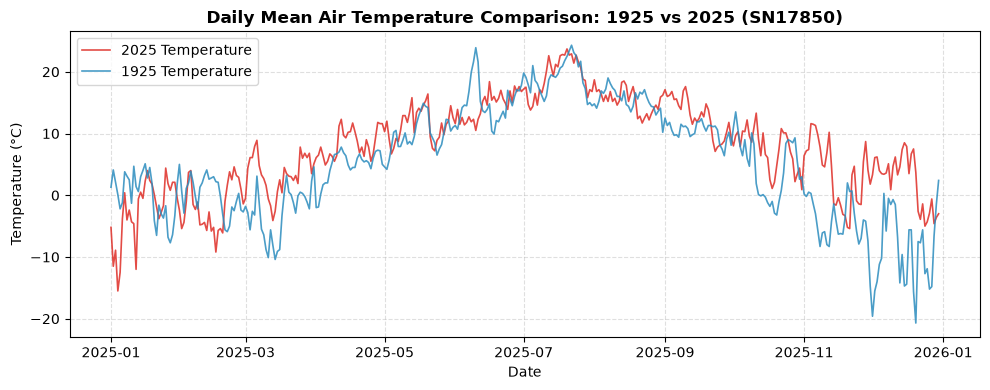


--- Temperature Comparison: 1925 vs 2025 ---
Metric  1925 (°C)  2025 (°C)
  Mean       5.31        7.9
Median       5.30        8.4
   Min     -20.70      -15.5
   Max      24.30       23.7


In [8]:
# Load the data from 100 years ago
parameters_1925 = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "1925-01-01/1925-12-31",
}

resp_1925 = requests.get(endpoint, parameters_1925, auth=(CLIENT_ID, ""))
json_1925 = resp_1925.json()

# Transform to dataframe named df_1925
df_1925 = pd.DataFrame(
    [
        {
            "referenceTime": item["referenceTime"],
            "temp_1925": item["observations"][0]["value"],
        }
        for item in json_1925["data"]
    ]
)

df_1925["referenceTime"] = pd.to_datetime(df_1925["referenceTime"])
df_1925.set_index("referenceTime", inplace=True)

# Merge with current dataframe
# take in only those day records same as of current df
df["temp_1925"] = df_1925["temp_1925"].values[: len(df)]

# Plot
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(
    df.index,
    df["value"],
    color="#de2d26",
    linewidth=1.2,
    alpha=0.85,
    label="2025 Temperature",
)
plt.plot(
    df.index,
    df["temp_1925"],
    color="#2b8cbe",
    linewidth=1.2,
    alpha=0.85,
    label="1925 Temperature",
)

plt.title(
    "Daily Mean Air Temperature Comparison: 1925 vs 2025 (SN17850)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=10)
plt.ylabel("Temperature (°C)", fontsize=10)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Summary Table
summary_3 = pd.DataFrame(
    {
        "Metric": ["Mean", "Median", "Min", "Max"],
        "1925 (°C)": [
            df["temp_1925"].mean(),
            df["temp_1925"].median(),
            df["temp_1925"].min(),
            df["temp_1925"].max(),
        ],
        "2025 (°C)": [
            df["value"].mean(),
            df["value"].median(),
            df["value"].min(),
            df["value"].max(),
        ],
    }
).round(2)

print("\n--- Temperature Comparison: 1925 vs 2025 ---")
print(summary_3.to_string(index=False))